In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Features Shape :", X.shape)
print("Labels Shape :", y.shape)

Features Shape : (569, 30)
Labels Shape : (569,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
model = LogisticRegression(max_iter=10000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [5]:
# Accuracy Score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.956140350877193


In [6]:
print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 95.61%


In [7]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

precision = precision_score(y_test, y_pred)

print(f"Precision : {precision:.4f}")

recall = recall_score(y_test, y_pred)

print(f"Recall : {recall:.4f}")

f1 = f1_score(y_test, y_pred)

print(f"F1 Score : {f1:.4f}")

print(classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

Accuracy : 0.9561
Precision : 0.9459
Recall : 0.9859
F1 Score : 0.9655
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



NameError: name 'cm' is not defined

Accuracy : 0.9561
Precision : 0.9459
Recall : 0.9859
F1 Score : 0.9655
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



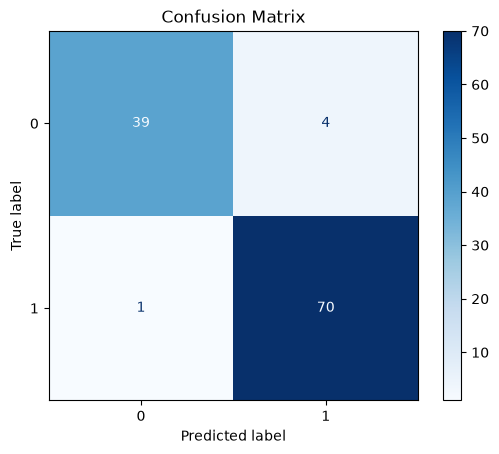

In [8]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}")

precision = precision_score(y_test, y_pred)
print(f"Precision : {precision:.4f}")

recall = recall_score(y_test, y_pred)
print(f"Recall : {recall:.4f}")

f1 = f1_score(y_test, y_pred)
print(f"F1 Score : {f1:.4f}")

print(classification_report(y_test, y_pred))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

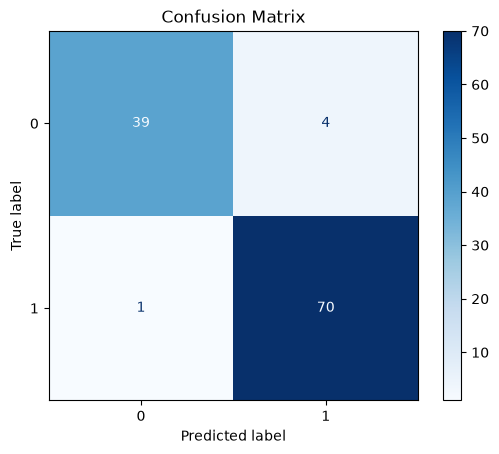

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [10]:
# Probability of belonging to the positive class (class = 1)

y_prob = model.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[8.78417737e-01 3.04735433e-08 1.59969809e-03 9.98775726e-01
 9.99858607e-01 2.00253498e-10 6.15347950e-11 1.92820681e-02
 9.84264981e-01 9.94311003e-01]


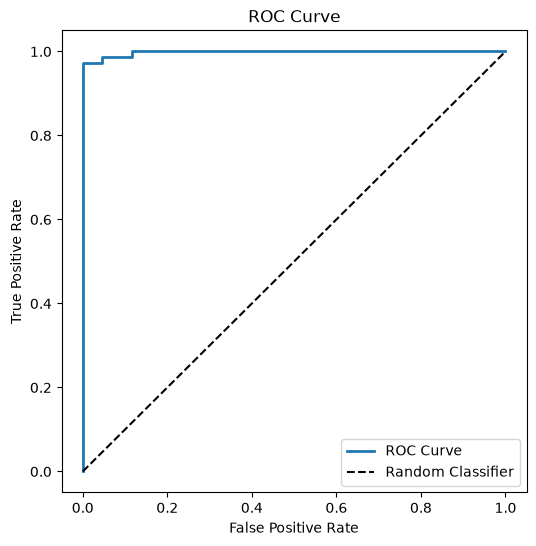

In [11]:
# Compute ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 6))

plt.plot(fpr, tpr, label="ROC Curve", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [12]:
auc = roc_auc_score(y_test, y_prob)

print(f"AUC Score : {auc:.4f}")

AUC Score : 0.9977


In [13]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

results

,Metric,Score
0,Accuracy,0.956140
1,Precision,0.945946
2,Recall,0.985915
3,F1 Score,0.965517
4,ROC AUC,0.997707
